# Imports

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from math import pi


In [ ]:
# Change directory
import os
os.chdir('/content/drive/MyDrive/nids-mitre/')

!pwd


/content/drive/MyDrive/nids-mitre


# Functions

## Load data

In [ ]:
def load_json_data(files):
    results = {}
    losses = {}

    for name, path in files.items():
        try:
            with open(path, 'r') as f:
                data = json.load(f)

            results[name] = {
                'AUC-PR': data['summary']['best_aucpr'],
                'F1-Score': data['summary']['best_f1']
            }

            if 'losses' in data:
                losses[name] = data['losses']

        except FileNotFoundError:
            print(f"File not found: {path}")

    return results, losses

In [ ]:
def load_and_merge_csv_data(files_dict):
    df_list = []

    for model_name, filepath in files_dict.items():
        try:
            # Read CSV
            df = pd.read_csv(filepath)

            # Normalize column names to lowercase
            df.columns = df.columns.str.lower().str.strip()

            # Add identifier column
            df['Model'] = model_name

            # Check if there is data
            if len(df) > 0:
                print(f"{model_name}: Loaded {len(df)} seeds.")
                df_list.append(df)
            else:
                print(f"{model_name}: The file is empty.")

        except FileNotFoundError:
            print(f"{model_name}: The file was not found: '{filepath}'")

    if not df_list:
        return None

    # Concatenate into a single DataFrame
    full_df = pd.concat(df_list, ignore_index=True)

    return full_df

## Training losses

In [ ]:
def plot_training_losses(losses_data):
    plt.figure(figsize=(12, 6))

    for name, seed_losses_dict in losses_data.items():
        # seed_losses_dict is a dict like {'seed_42': {'train': [...], 'val': [...]}, ...}

        # Collect all train loss histories for this model
        all_train_losses_for_model = [seed_data['train'] for seed_data in seed_losses_dict.values()]

        # Find the minimum length in case any seed stopped before
        min_len = min(len(lst) for lst in all_train_losses_for_model)

        # Create a matrix from the truncated train loss histories
        matrix = np.array([lst[:min_len] for lst in all_train_losses_for_model])

        # meand and std
        mean_loss = np.mean(matrix, axis=0)
        std_loss = np.std(matrix, axis=0)
        epochs = range(1, len(mean_loss) + 1)

        # Plot
        plt.plot(epochs, mean_loss, label=name, color=colors[name], linewidth=2)
        plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                         color=colors[name], alpha=0.15)

    plt.title("Training Stability & Convergence", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Training Loss")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.savefig("training_losses.png", dpi=300)
    plt.show()


In [ ]:
def plot_losses_train_val(data_json, model_name):
    with open(data_json, 'r') as f: data = json.load(f)

    plt.figure(figsize=(12, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, (seed_name, losses) in enumerate(data['losses'].items()):
        train = losses['train']
        val = losses['val']
        epochs = range(1, len(train) + 1)

        color = colors[i % len(colors)]

        # Solid line = Training
        plt.plot(epochs, train, linestyle='-', color=color, alpha=0.6, label=f'{seed_name} Train')
        # Dashed line = Validation
        plt.plot(epochs, val, linestyle='--', color=color, linewidth=2, label=f'{seed_name} Val')

    plt.title(f"{model_name} - Train (Solid) vs Validation (Dashed) Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## Comparative bar chart (with error bars)

In [ ]:
def plot_comparison(results):
    metrics = ['AUC-PR', 'F1-Score']

    rows = []
    for model_name, metrics_dict in results.items():
        for metric_name, values in metrics_dict.items():
            for val in values:
                rows.append({
                    'Model': model_name,
                    'Metric': metric_name,
                    'Value': val
                })
    df = pd.DataFrame(rows)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    g = sns.barplot(data=df, x='Metric', y='Value', hue='Model',
                    palette=colors, errorbar='sd', capsize=0.1, alpha=0.9)

    plt.title("Model Comparison (Threshold=0.5 for F1)", fontsize=14)
    plt.ylim(0.0, 1.0)
    plt.legend(title='Architecture', loc='lower right')
    plt.ylabel("Score")
    plt.xlabel("")

    plt.tight_layout()
    plt.savefig("comparison_barplot.png", dpi=300)
    plt.show()
    return df

## Radar chart

In [ ]:
def plot_radar_chart(df):
    # Group by model and calculate average
    # Select only numeric columns for the average
    df_avg = df.groupby('Model').mean(numeric_only=True).reset_index()

    metrics_to_plot = ['f1', 'f2', 'precision', 'recall']

    # Prepare the plot
    categories = [m.upper() for m in metrics_to_plot]
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Closing the circle

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    # Axes and Labels
    plt.xticks(angles[:-1], categories, color='black', size=12)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
    plt.ylim(0, 1)

    draw_order = ["Simple MLP", "Edge GRU", "Static GNN", "ST-GNN (Ours)"]

    for model_name in draw_order:
        if model_name not in df_avg['Model'].values: continue

        # Obtain values ​​and close the circle
        values = df_avg[df_avg['Model'] == model_name][metrics_to_plot].values.flatten().tolist()
        values += values[:1]

        col = colors.get(model_name, 'black')

        # Draw line and fill
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color=col)
        ax.fill(angles, values, color=col, alpha=0.1)

    plt.title("Multidimensional Performance Analysis (threshold=0.5)", size=16, y=1.05, weight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=10)

    plt.tight_layout()
    plt.savefig("radar_chart_comparison.png", dpi=300)
    plt.show()

## Summary table

In [ ]:
def generate_summary_table(df):
    # Lista de métricas a mostrar
    possible_metrics = ['auc', 'auc-pr', 'f1', 'f2', 'precision', 'recall', 'accuracy', 'fpr']
    metrics = [c for c in df.columns if any(pm in c for pm in possible_metrics)]

    # Define the desired order for models
    model_order = ["Simple MLP", "Edge GRU", "Static GNN", "ST-GNN (Ours)"]

    # Convert 'Model' column to categorical type with the desired order
    df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)

    # Agrupar
    summary = df.groupby('Model', observed=False)[metrics].agg(['mean', 'std'])

    print("\n" + "="*50)
    print("SUMMARY (Mean ± Std) FOR THRESHOLD=0.5")
    print("="*50)
    print(summary)

# Configuration

In [ ]:
json_files = {
    "Simple MLP": "/content/drive/MyDrive/nids-mitre/logs/curves_multiseed_SimpleMLP_BiasOn.json",
    "Edge GRU": "/content/drive/MyDrive/nids-mitre/logs/curves_multiseed_EdgeGRU_BiasOn.json",
    "Static GNN": "/content/drive/MyDrive/nids-mitre/logs/curves_multiseed_StaticGNN_BiasOn_robust_Identity.json",
    "ST-GNN (Ours)": "/content/drive/MyDrive/nids-mitre/logs/curves_multiseed_ST_GNN_BiasOn_robust_Identity_clone.json"
}

csv_files = {
    "Simple MLP": "/content/drive/MyDrive/nids-mitre/logs/simpleMLP_biasinit.csv",
    "Edge GRU": "/content/drive/MyDrive/nids-mitre/logs/edge_gru_biasinit.csv",
    "Static GNN": "/content/drive/MyDrive/nids-mitre/logs/static_gnn_biasinit_robust_identity.csv",
    "ST-GNN (Ours)": "/content/drive/MyDrive/nids-mitre/logs/st_gnn_biasinit_robust_identity_clone.csv"
}

colors = {
    "Simple MLP": "#95a5a6",   # Gray
    "Edge GRU": "#3498db",   # Blue
    "Static GNN": "#e67e22",     # Orange
    "ST-GNN (Ours)": "#2ecc71" # Green
}

# Main

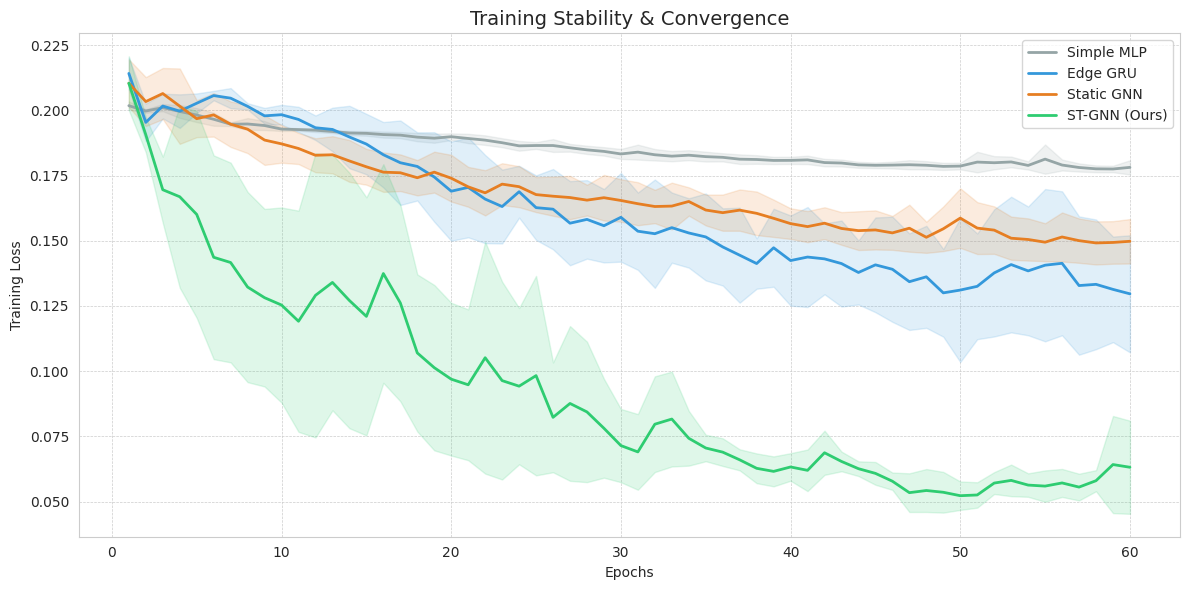

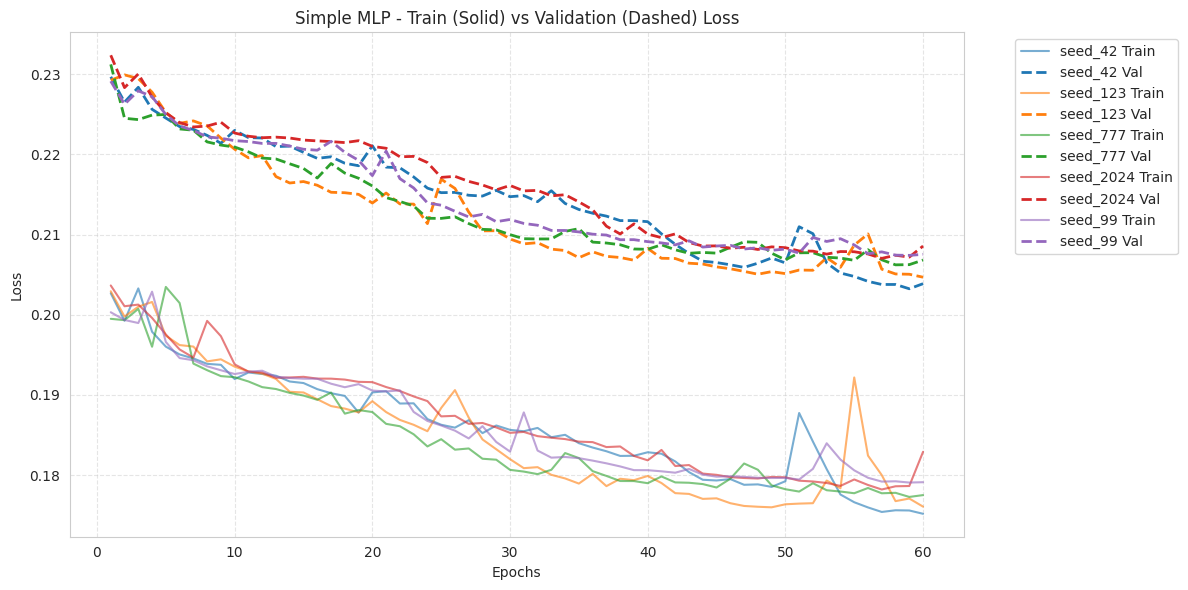

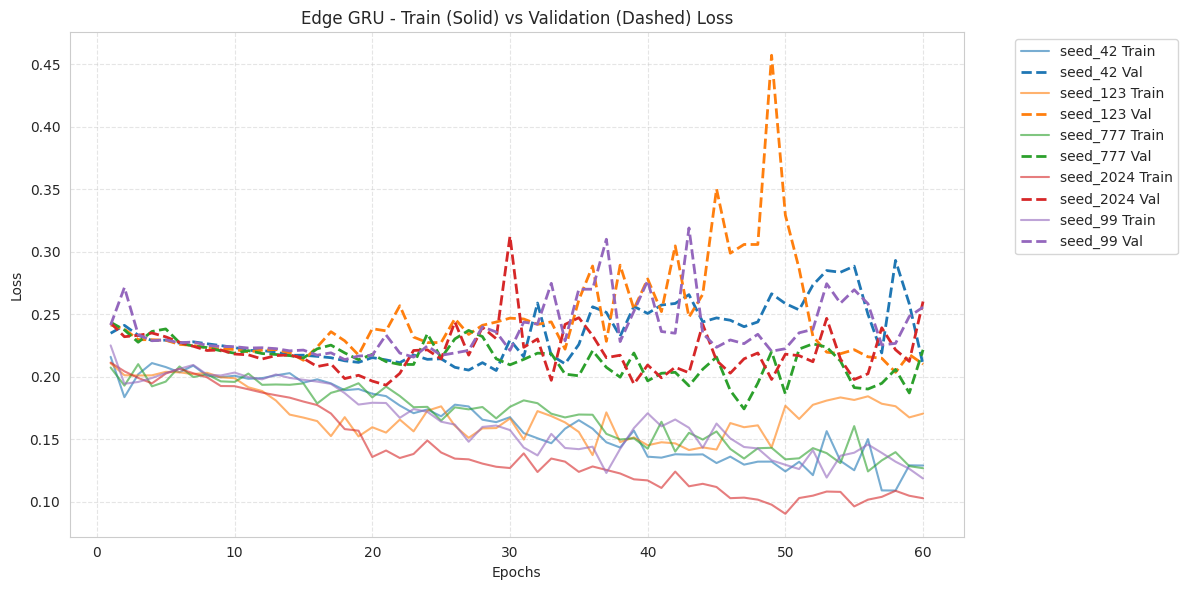

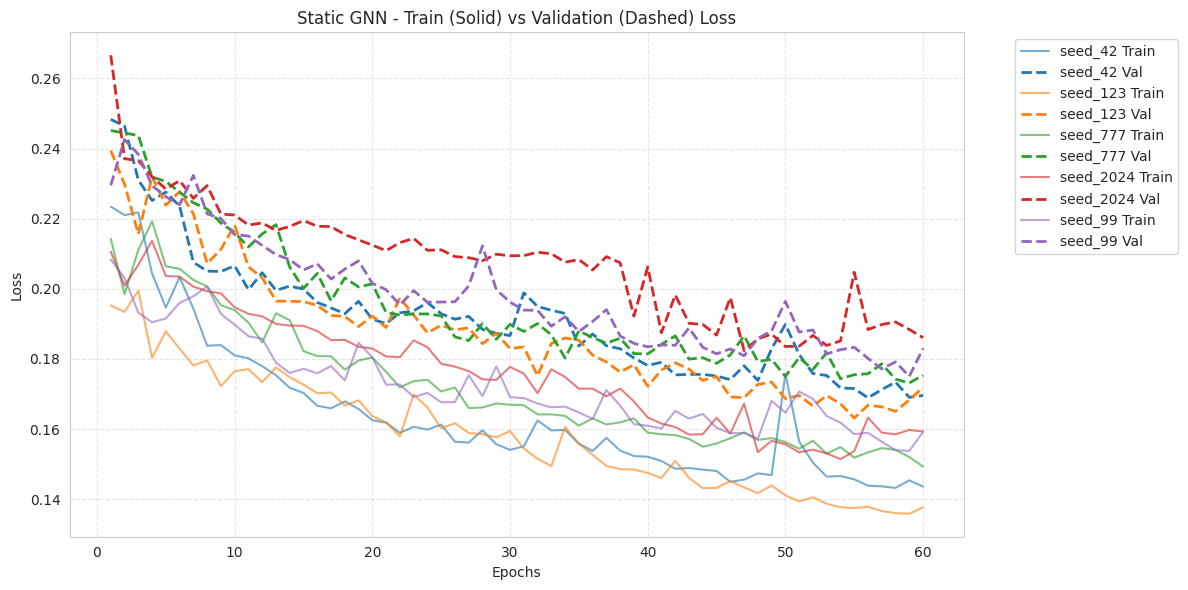

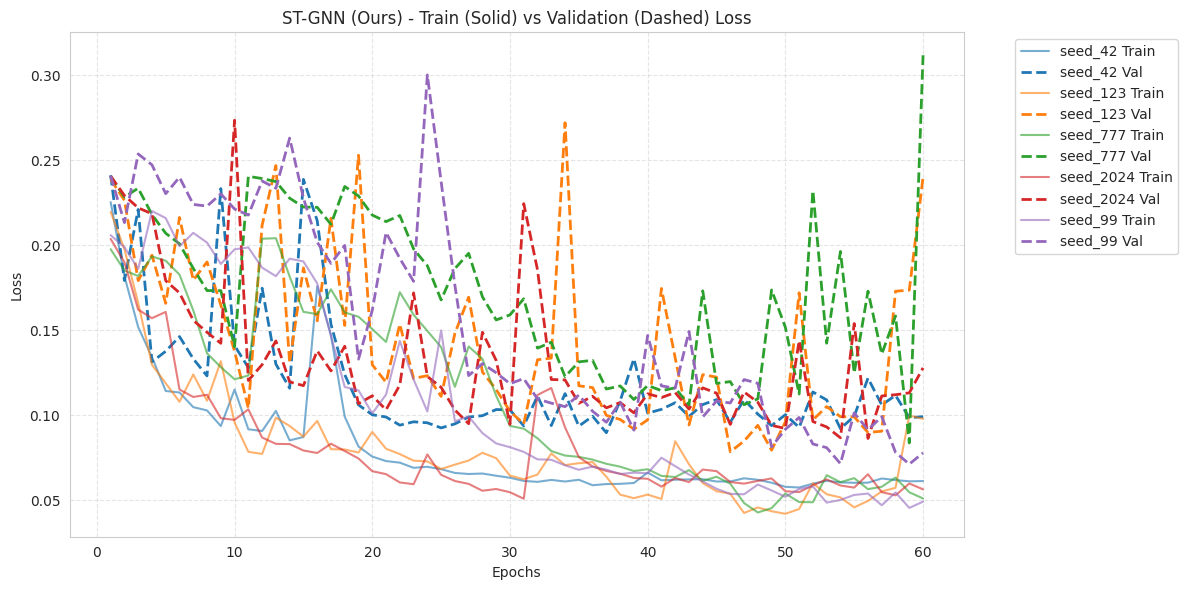

In [ ]:
results, losses = load_json_data(json_files)

plot_training_losses(losses)

for model_name, filename in json_files.items():
    plot_losses_train_val(filename, model_name)


Simple MLP: Loaded 5 seeds.
Edge GRU: Loaded 5 seeds.
Static GNN: Loaded 5 seeds.
ST-GNN (Ours): Loaded 5 seeds.


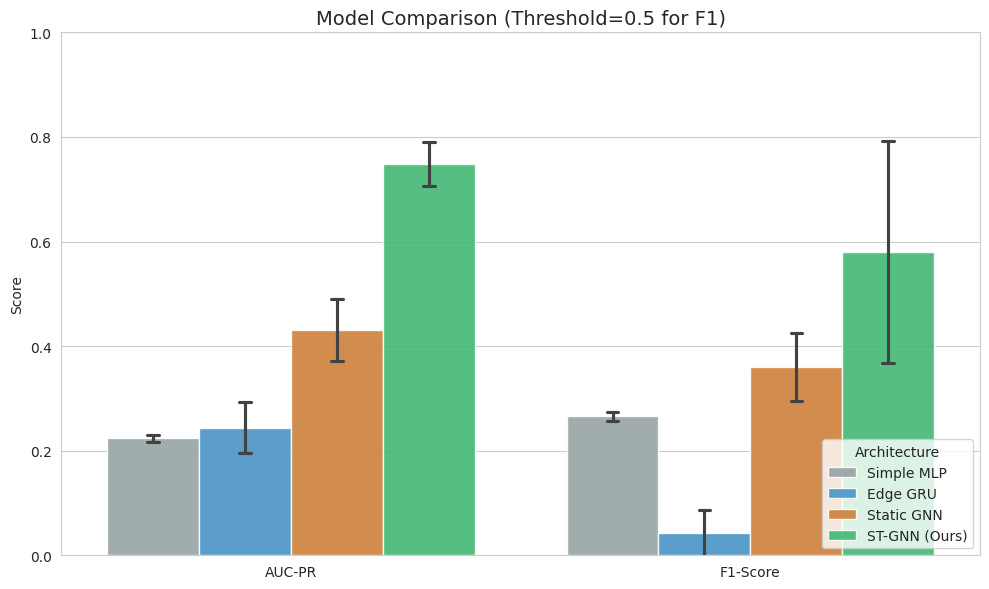

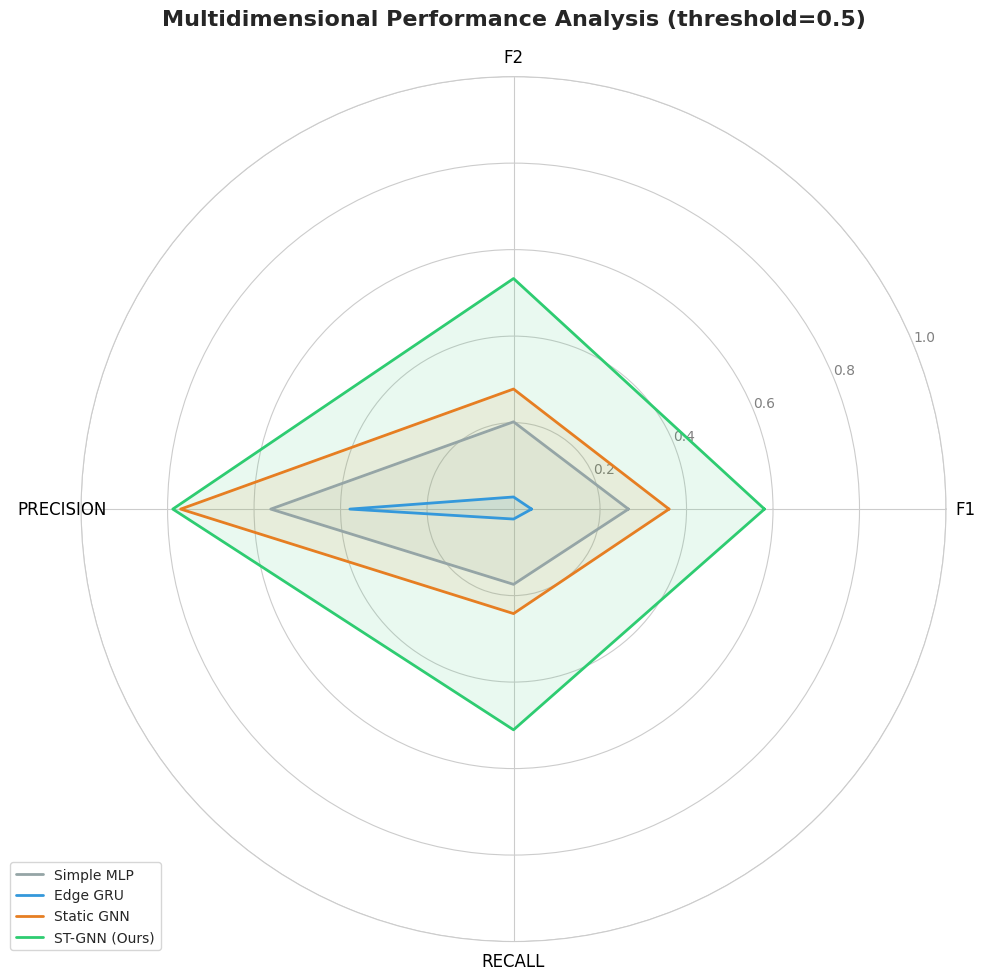

In [ ]:
full_data = load_and_merge_csv_data(csv_files)

df = plot_comparison(results)
plot_radar_chart(full_data)


In [ ]:
generate_summary_table(full_data)


SUMMARY (Mean ± Std) FOR THRESHOLD=0.5
              precision              recall                  f1            \
                   mean       std      mean       std      mean       std   
Model                                                                       
Simple MLP     0.561340  0.010528  0.173999  0.006649  0.265633  0.008802   
Edge GRU       0.378485  0.233010  0.023007  0.025224  0.041826  0.044662   
Static GNN     0.769696  0.127992  0.241642  0.065865  0.359575  0.064658   
ST-GNN (Ours)  0.787926  0.065770  0.510390  0.253616  0.580293  0.211989   

                     f2              auc-pr             auc-roc            \
                   mean       std      mean       std      mean       std   
Model                                                                       
Simple MLP     0.201850  0.007398  0.223414  0.006919  0.806859  0.003951   
Edge GRU       0.028047  0.030529  0.244047  0.049238  0.840290  0.035675   
Static GNN     0.277647  0.067256  